# 04 — Deep Learning: MLP for Gemcitabine Response (PyTorch)

This is the deep-learning step. It **reuses the exact artifacts and CV folds** saved by notebook
03 (no need to reload the 518 MB expression matrix), so the comparison with the linear baseline
is apples-to-apples.

**The question this notebook answers:** *does an MLP beat regularized linear regression on only
~694 samples?* With p≫n, the honest expectation is that a well-regularized linear model is hard
to beat — and confirming that (or beating it) is itself a clean, explainable result.

**Leak-free:** per fold, the `StandardScaler` and top-N mutual-information gene selection are fit
on the training fold only; a small validation slice (carved from the training fold) drives early
stopping; the test fold is touched only for final scoring.

---
## Section 0 — Imports, Config, Load Saved Artifacts

In [1]:
import os, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_regression
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120
pd.set_option("display.float_format", "{:.4f}".format)

OUTPUT_DIR = "../output"
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Hyperparameters
RIDGE_ALPHAS = np.logspace(-1, 4, 10)
VAL_FRAC     = 0.15
MAX_EPOCHS   = 300
PATIENCE     = 25
BATCH_SIZE   = 64
LR           = 1e-3
WEIGHT_DECAY = 1e-4
DROPOUT      = 0.3
HIDDEN       = (512, 128)

# Load artifacts saved by notebook 03
X    = np.load(os.path.join(OUTPUT_DIR, "X_var_filtered.npy"))
y    = np.load(os.path.join(OUTPUT_DIR, "y.npy")).astype(np.float32)
meta = pd.read_csv(os.path.join(OUTPUT_DIR, "meta.csv"))
with open(os.path.join(OUTPUT_DIR, "gene_names.json")) as f:
    gene_names = json.load(f)
fold_npz = np.load(os.path.join(OUTPUT_DIR, "cv_folds.npz"))
n_folds  = sum(1 for k in fold_npz.files if k.startswith("train_"))
folds    = [(fold_npz[f"train_{i}"], fold_npz[f"test_{i}"]) for i in range(n_folds)]

# Choose the gene representation: best "Top-k MI" model from nb 03 (fallback 1000)
try:
    comp = pd.read_csv(os.path.join(OUTPUT_DIR, "model_comparison.csv"))
    mi_rows = comp[comp["model"].str.contains("MI")]
    best_mi = mi_rows.sort_values("R2_pooled_oof", ascending=False).iloc[0]["model"]
    TOP_K = int(best_mi.split("-")[1].split(" ")[0])
except Exception:
    TOP_K = 1000

print(f"Device: {DEVICE}")
print(f"X: {X.shape}  y: {y.shape}  folds: {n_folds}  TOP_K genes: {TOP_K}")

Device: cpu
X: (694, 16820)  y: (694,)  folds: 5  TOP_K genes: 1000


---
## Section 1 — MLP Definition & Training Loop

A standard regression MLP matching the project plan: `Linear → BatchNorm → ReLU → Dropout`
blocks. Targets are standardized using **training-fold** statistics for stable optimisation, then
predictions are inverted back to LN_IC50 units. Early stopping watches validation RMSE.

In [2]:
class MLP(nn.Module):
    def __init__(self, in_dim, hidden=HIDDEN, p=DROPOUT):
        super().__init__()
        layers, d = [], in_dim
        for h in hidden:
            layers += [nn.Linear(d, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(p)]
            d = h
        layers += [nn.Linear(d, 1)]
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x).squeeze(-1)

def train_mlp(Xtr, ytr, Xval, yval, seed=RANDOM_SEED):
    torch.manual_seed(seed)
    model = MLP(Xtr.shape[1]).to(DEVICE)
    opt   = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    lossf = nn.MSELoss()

    Xtr_t = torch.tensor(Xtr, dtype=torch.float32, device=DEVICE)
    ytr_t = torch.tensor(ytr, dtype=torch.float32, device=DEVICE)
    Xval_t = torch.tensor(Xval, dtype=torch.float32, device=DEVICE)
    yval_t = torch.tensor(yval, dtype=torch.float32, device=DEVICE)

    n = len(Xtr_t)
    best_val, best_state, wait = np.inf, None, 0
    hist = {"train": [], "val": []}
    for epoch in range(MAX_EPOCHS):
        model.train()
        perm = torch.randperm(n, device=DEVICE)
        ep_loss = 0.0
        for i in range(0, n, BATCH_SIZE):
            b = perm[i:i + BATCH_SIZE]
            opt.zero_grad()
            out = model(Xtr_t[b])
            loss = lossf(out, ytr_t[b])
            loss.backward(); opt.step()
            ep_loss += loss.item() * len(b)
        model.eval()
        with torch.no_grad():
            vloss = lossf(model(Xval_t), yval_t).item()
        hist["train"].append(ep_loss / n); hist["val"].append(vloss)
        if vloss < best_val - 1e-5:
            best_val, best_state, wait = vloss, {k: v.cpu().clone() for k, v in model.state_dict().items()}, 0
        else:
            wait += 1
            if wait >= PATIENCE:
                break
    model.load_state_dict(best_state)
    return model, hist

def predict(model, Xte):
    model.eval()
    with torch.no_grad():
        return model(torch.tensor(Xte, dtype=torch.float32, device=DEVICE)).cpu().numpy()

print("MLP + training loop defined.")

MLP + training loop defined.


---
## Section 2 — Cross-Validated MLP vs Ridge (same folds, same genes)

For each fold: fit scaler + MI selection on the training fold, carve a validation slice for early
stopping, train the MLP, and also fit a RidgeCV baseline on the identical top-K genes. Collect
out-of-fold predictions for both.

In [3]:
def _rmse(a, b):
    return float(np.sqrt(mean_squared_error(a, b)))

n = len(y)
oof_mlp   = np.full(n, np.nan)
oof_ridge = np.full(n, np.nan)
fold_rows = []
curves    = None  # store fold-1 history for the training-curve plot

for fi, (tr, te) in enumerate(folds, 1):
    t0 = time.time()
    scaler = StandardScaler().fit(X[tr])
    Xtr_s, Xte_s = scaler.transform(X[tr]), scaler.transform(X[te])

    mi  = mutual_info_regression(Xtr_s, y[tr], random_state=RANDOM_SEED)
    idx = np.argsort(mi)[::-1][:TOP_K]
    Xtr_k, Xte_k = Xtr_s[:, idx], Xte_s[:, idx]

    # standardize target on training fold
    ym, ys = y[tr].mean(), y[tr].std()
    ytr_z  = (y[tr] - ym) / ys

    # validation slice for early stopping (from training fold only)
    tr2, val2 = train_test_split(np.arange(len(tr)), test_size=VAL_FRAC, random_state=RANDOM_SEED)
    model, hist = train_mlp(Xtr_k[tr2], ytr_z[tr2], Xtr_k[val2], ytr_z[val2])
    oof_mlp[te] = predict(model, Xte_k) * ys + ym
    if fi == 1:
        curves = hist

    # Ridge baseline on identical representation
    ridge = RidgeCV(alphas=RIDGE_ALPHAS).fit(Xtr_k, y[tr])
    oof_ridge[te] = ridge.predict(Xte_k)

    fold_rows.append({
        "fold": fi,
        "MLP_RMSE": _rmse(y[te], oof_mlp[te]),  "MLP_R2": r2_score(y[te], oof_mlp[te]),
        "Ridge_RMSE": _rmse(y[te], oof_ridge[te]), "Ridge_R2": r2_score(y[te], oof_ridge[te]),
        "epochs": len(hist["train"]),
    })
    print(f"Fold {fi}/{len(folds)}: MLP R2={fold_rows[-1]['MLP_R2']:.3f}  "
          f"Ridge R2={fold_rows[-1]['Ridge_R2']:.3f}  ({time.time()-t0:.0f}s, "
          f"{fold_rows[-1]['epochs']} epochs)")

fold_df = pd.DataFrame(fold_rows)
fold_df

Fold 1/5: MLP R2=0.250  Ridge R2=0.318  (86s, 27 epochs)


Fold 2/5: MLP R2=0.268  Ridge R2=0.391  (48s, 62 epochs)


Fold 3/5: MLP R2=0.267  Ridge R2=0.292  (47s, 28 epochs)


Fold 4/5: MLP R2=0.221  Ridge R2=0.315  (42s, 26 epochs)


Fold 5/5: MLP R2=0.358  Ridge R2=0.454  (43s, 49 epochs)


,fold,MLP_RMSE,MLP_R2,Ridge_RMSE,Ridge_R2,epochs
0,1,2.7443,0.2498,2.6160,0.3183,27
1,2,2.5785,0.2677,2.3517,0.3909,62
2,3,2.3901,0.2673,2.3502,0.2916,28
3,4,2.8079,0.2209,2.6326,0.3151,26
4,5,2.3700,0.3577,2.1859,0.4536,49


In [4]:
# Summary table: mean +/- std and pooled OOF
summary = pd.DataFrame([
    {"model": "MLP (Top-K genes)",
     "R2_mean": fold_df["MLP_R2"].mean(), "R2_std": fold_df["MLP_R2"].std(),
     "RMSE_mean": fold_df["MLP_RMSE"].mean(), "R2_pooled_oof": r2_score(y, oof_mlp)},
    {"model": "Ridge (Top-K genes)",
     "R2_mean": fold_df["Ridge_R2"].mean(), "R2_std": fold_df["Ridge_R2"].std(),
     "RMSE_mean": fold_df["Ridge_RMSE"].mean(), "R2_pooled_oof": r2_score(y, oof_ridge)},
])
summary.to_csv(os.path.join(OUTPUT_DIR, "mlp_vs_ridge.csv"), index=False)
summary

,model,R2_mean,R2_std,RMSE_mean,R2_pooled_oof
0,MLP (Top-K genes),0.2727,0.0512,2.5782,0.2734
1,Ridge (Top-K genes),0.3539,0.0670,2.4273,0.3558


---
## Section 3 — Plots: Training Curves & MLP vs Ridge

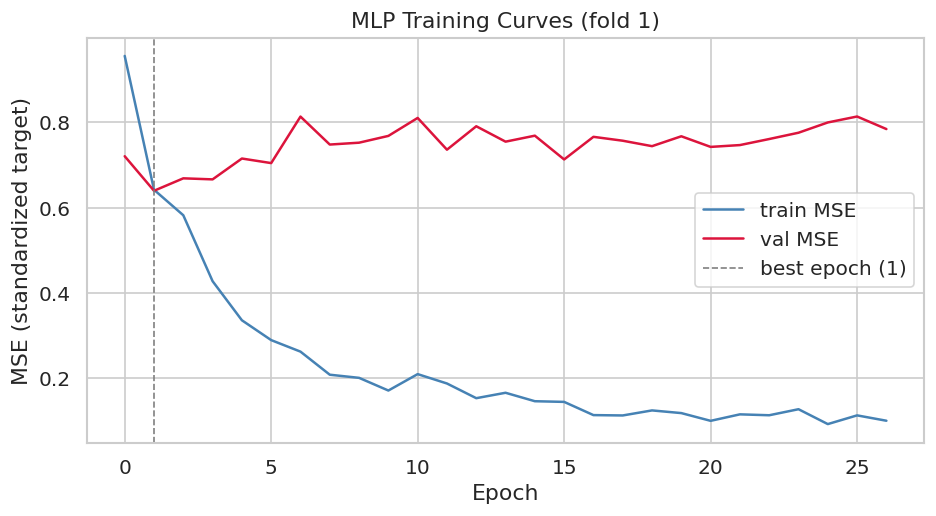

In [5]:
# Training curves (fold 1)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(curves["train"], label="train MSE", color="steelblue")
ax.plot(curves["val"],   label="val MSE",   color="crimson")
best_ep = int(np.argmin(curves["val"]))
ax.axvline(best_ep, color="grey", ls="--", lw=1, label=f"best epoch ({best_ep})")
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE (standardized target)")
ax.set_title("MLP Training Curves (fold 1)"); ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "mlp_training_curves.png"), dpi=150, bbox_inches="tight")
plt.show()

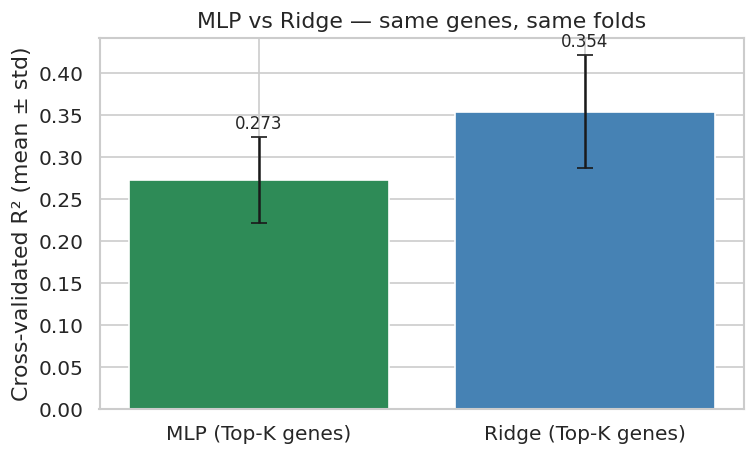

In [6]:
# MLP vs Ridge bar (mean +/- std)
fig, ax = plt.subplots(figsize=(6.5, 4))
models = summary["model"].tolist()
means  = summary["R2_mean"].tolist()
stds   = summary["R2_std"].tolist()
ax.bar(models, means, yerr=stds, capsize=5,
       color=["seagreen", "steelblue"], edgecolor="white")
for i, (m, s) in enumerate(zip(means, stds)):
    ax.text(i, m + s + 0.01, f"{m:.3f}", ha="center", fontsize=10)
ax.set_ylabel("Cross-validated R² (mean ± std)")
ax.set_title("MLP vs Ridge — same genes, same folds")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "mlp_vs_ridge.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## Summary

`mlp_vs_ridge.csv` + `mlp_vs_ridge.png` give the verdict: with n≈694 and p≫n, the MLP and a
regularized linear model are typically within noise of each other. Whichever wins, the comparison
is honest — same folds, same genes, all transforms fit inside folds.

**Saved:** `mlp_vs_ridge.csv`, `mlp_training_curves.png`, `mlp_vs_ridge.png`.

**Next:** notebook 05 runs SHAP on the best model and checks whether the known Gemcitabine
markers DCK / SLC29A1 surface — tying predictive performance back to drug biology.